# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Willy Aldo
- **Email:** cdcc409d6y1792@student.devacademy.id
- **ID Dicoding:** CDCC409D6Y1792

## Menentukan Pertanyaan Bisnis

- Pertanyaan 1
Bagaimana tren jumlah penyewaan sepeda per bulan selama tahun 2011 hingga 2012?
- Pertanyaan 2
Pada jam berapa penyewaan sepeda mencapai titik tertinggi dalam sehari?

## Import Semua Packages/Library yang Digunakan

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [2]:
day_df = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vRQ5XjLgBUPJPxDnmZ98n5JJvMppuPEesz5ArTgfXUVq20rWOGKnYFRsQpivqgPQuRcmk1R3KgidrlW/pub?output=csv")
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,344.167,363.625,805.833,160.446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,363.478,353.739,696.087,248.539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,196.364,189.405,437.273,248.309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200,212.122,590.435,160.296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,226.957,22.927,436.957,1.869,82,1518,1600


In [3]:
hour_df = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vSacj0RBVBcMXMD12JtlZ9WEAFoDKZmQM1tQNu_RT3Kz4-JAfa55IaOMqyGu_ieqLOkUub9ZIJqhIBU/pub?output=csv")
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,2.879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,2.727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,2.727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,2.879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,2.879,0.75,0.0,0,1,1


**Insight:**
- Pada tahap ini Data berhasil dimuat. day_df memiliki 731 baris yang berisi data harian, sementara hour_df memberikan detail per jam. Data ini siap untuk masuk ke tahap pemeriksaan.

### Assessing Data

In [4]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [5]:
day_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


In [6]:
print("Jumlah duplikasi: ", day_df.duplicated().sum())

Jumlah duplikasi:  0


In [7]:
day_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,382.176379,443.881906,462.942223,228.423079,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,265.084523,198.790487,287.913949,186.851297,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.150000,2.036000,0.000000,1.107000,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,181.527500,307.446000,77.750000,136.514500,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,385.833000,463.375000,542.917000,187.808000,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,621.667000,603.554000,687.292000,251.831000,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,973.913000,988.391000,970.417000,995.125000,3410.000000,6946.000000,8714.000000


In [8]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [9]:
hour_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


In [10]:
print("Jumlah duplikasi: ", hour_df.duplicated().sum())

Jumlah duplikasi:  0


In [11]:
hour_df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,40.795344,0.627229,93.699267,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,139.041539,0.192930,246.412443,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,3.333000,0.480000,1.343000,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,5.152000,0.630000,2.239000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,6.364000,0.780000,3.881000,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,909.000000,1.000000,896.000000,367.000000,886.000000,977.000000


**Insight:**
- Berdasarkan hasil pemeriksaan pada kedua dataset, terlihat bahwa day_df dan hour_df memiliki kualitas data yang sangat baik karena tidak ditemukan adanya missing values maupun baris data yang duplikat di seluruh kolom.
- Namun, terdapat ketidakkonsistenan pada tipe data kolom dteday di kedua dataset yang masih terbaca sebagai object, padahal kolom tersebut merepresentasikan data tanggal. Selain itu, beberapa kolom kategorikal seperti season, yr, dan mnth masih dalam bentuk numerik yang kurang informatif bagi audiens awam. Oleh karena itu, diperlukan proses cleaning untuk mengonversi tipe data tanggal dan melakukan mapping label kategori agar analisis serta visualisasi yang dihasilkan nantinya menjadi lebih akurat dan mudah dipahami.

### Cleaning Data

In [12]:
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

print("Tampilan Data Harian (Setelah Konversi Tanggal):")
display(day_df.head())

print("\nInformasi Tipe Data:")
day_df.info()

Tampilan Data Harian (Setelah Konversi Tanggal):


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,344.167,363.625,805.833,160.446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,363.478,353.739,696.087,248.539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,196.364,189.405,437.273,248.309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200,212.122,590.435,160.296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,226.957,22.927,436.957,1.869,82,1518,1600



Informasi Tipe Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    int64         
 3   yr          731 non-null    int64         
 4   mnth        731 non-null    int64         
 5   holiday     731 non-null    int64         
 6   weekday     731 non-null    int64         
 7   workingday  731 non-null    int64         
 8   weathersit  731 non-null    int64         
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         
dtypes: d

In [13]:
day_df['season'] = day_df['season'].map({
    1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'
})

day_df['yr'] = day_df['yr'].map({
    0: '2011', 1: '2012'
})

day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,Spring,2011,1,0,6,0,2,344.167,363.625,805.833,160.446,331,654,985
1,2,2011-01-02,Spring,2011,1,0,0,0,2,363.478,353.739,696.087,248.539,131,670,801
2,3,2011-01-03,Spring,2011,1,0,1,1,1,196.364,189.405,437.273,248.309,120,1229,1349
3,4,2011-01-04,Spring,2011,1,0,2,1,1,0.200,212.122,590.435,160.296,108,1454,1562
4,5,2011-01-05,Spring,2011,1,0,3,1,1,226.957,22.927,436.957,1.869,82,1518,1600


**Insight:**
- Pada tahap cleanning ini, dilakukan perbaikan tipe data dan standarisasi label untuk memastikan data siap dianalisis. Kolom dteday pada kedua dataset diubah menjadi tipe datetime agar fitur pencatatan waktu dapat berfungsi secara optimal dalam analisis tren. Selain itu, dilakukan proses mapping pada kolom season dan yr untuk mengubah representasi angka menjadi label tekstual yang lebih intuitif.

## Exploratory Data Analysis (EDA)

### Explore ...

In [14]:
print("Dataframe yang digunakan untuk EDA:")
display(day_df.head())

print("\nEksplorasi Tren Penyewaan per Bulan (2011-2012):")
monthly_rent_df = day_df.resample(rule='ME', on='dteday').agg({
    "cnt": "sum"
})
display(monthly_rent_df)

Dataframe yang digunakan untuk EDA:


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,Spring,2011,1,0,6,0,2,344.167,363.625,805.833,160.446,331,654,985
1,2,2011-01-02,Spring,2011,1,0,0,0,2,363.478,353.739,696.087,248.539,131,670,801
2,3,2011-01-03,Spring,2011,1,0,1,1,1,196.364,189.405,437.273,248.309,120,1229,1349
3,4,2011-01-04,Spring,2011,1,0,2,1,1,0.200,212.122,590.435,160.296,108,1454,1562
4,5,2011-01-05,Spring,2011,1,0,3,1,1,226.957,22.927,436.957,1.869,82,1518,1600



Eksplorasi Tren Penyewaan per Bulan (2011-2012):


,cnt
dteday,
2011-01-31,38189
2011-02-28,48215
2011-03-31,64045
2011-04-30,94870
2011-05-31,135821
2011-06-30,143512
2011-07-31,141341
2011-08-31,136691
2011-09-30,127418


In [15]:
print("Statistik penyewaan sepeda per jam:")
hour_stats = hour_df.groupby(by="hr").agg({
    "cnt": ["max", "min", "mean", "std"]
})

display(hour_stats)

Statistik penyewaan sepeda per jam:


cnt                            
    max min        mean         std
hr                                 
0   283   2   53.898072   42.307910
1   168   1   33.375691   33.538727
2   132   1   22.869930   26.578642
3    79   1   11.727403   13.239190
4    28   1    6.352941    4.143818
5    66   1   19.889819   13.200765
6   213   1   76.044138   55.084348
7   596   1  212.064649  161.441936
8   839   5  359.011004  235.189285
9   426  14  219.309491   93.703458
10  539   8  173.668501  102.205413
11  663  10  208.143054  127.495536
12  776   3  253.315934  145.081134
13  760  11  253.661180  148.107657
14  750  12  240.949246  147.271574
15  750   7  251.233196  144.632541
16  783  11  311.983562  148.682618
17  976  15  461.452055  232.656611
18  977  23  425.510989  224.639304
19  743  11  311.523352  161.050359
20  567  11  226.030220  119.670164
21  584   6  172.314560   89.788893
22  502   9  131.335165   69.937782
23  256   2   87.831044   50.846889

In [16]:
#Penyewaan berdasarkan musim
day_df.groupby(by="season").agg({
    "cnt": ["max", "min", "mean", "std"]
})

cnt                                
         max   min         mean          std
season                                      
Fall    8714  1115  5644.303191  1459.800381
Spring  7836   431  2604.132597  1399.942119
Summer  8362   795  4992.331522  1695.977235
Winter  8555    22  4728.162921  1699.615261

In [17]:
# Penyewaan berdasarkan jam
hour_df.groupby(by="hr").agg({
    "cnt": ["max", "min", "mean", "std"]
})

cnt                            
    max min        mean         std
hr                                 
0   283   2   53.898072   42.307910
1   168   1   33.375691   33.538727
2   132   1   22.869930   26.578642
3    79   1   11.727403   13.239190
4    28   1    6.352941    4.143818
5    66   1   19.889819   13.200765
6   213   1   76.044138   55.084348
7   596   1  212.064649  161.441936
8   839   5  359.011004  235.189285
9   426  14  219.309491   93.703458
10  539   8  173.668501  102.205413
11  663  10  208.143054  127.495536
12  776   3  253.315934  145.081134
13  760  11  253.661180  148.107657
14  750  12  240.949246  147.271574
15  750   7  251.233196  144.632541
16  783  11  311.983562  148.682618
17  976  15  461.452055  232.656611
18  977  23  425.510989  224.639304
19  743  11  311.523352  161.050359
20  567  11  226.030220  119.670164
21  584   6  172.314560   89.788893
22  502   9  131.335165   69.937782
23  256   2   87.831044   50.846889

**Insight:**
- Pola Penyewaan Berdasarkan Jam:
Aktivitas penyewaan sepeda menunjukkan pola komuter yang sangat jelas dengan dua titik puncak utama pada pukul 08:00 pagi dan 17:00 sore, di mana rata-rata tertinggi mencapai 461 unit pada jam pulang kantor. Sebaliknya, penggunaan berada di titik terendah pada dini hari (00:00 - 04:00), yang mengonfirmasi bahwa armada paling banyak dimanfaatkan untuk mobilisasi harian pekerja dan pelajar dibandingkan untuk keperluan rekreasi di waktu malam.
- Pola Penyewaan Berdasarkan Musim:
Dari sisi musiman, Musim Gugur (Fall) menjadi periode paling produktif dengan rata-rata harian mencapai 5.644 unit, jauh melampaui Musim Semi (Spring) yang berada di posisi terendah dengan hanya 2.604 unit. Penurunan drastis pada musim semi ini menjadi temuan krusial yang menunjukkan adanya faktor eksternal seperti cuaca yang signifikan membatasi minat pengguna, sementara musim panas dan dingin cenderung tetap stabil di angka 4.700 hingga 4.900 unit.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

/tmp/ipykernel_6452/3950395629.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_rent_df = day_df.resample(rule='M', on='dteday').agg({


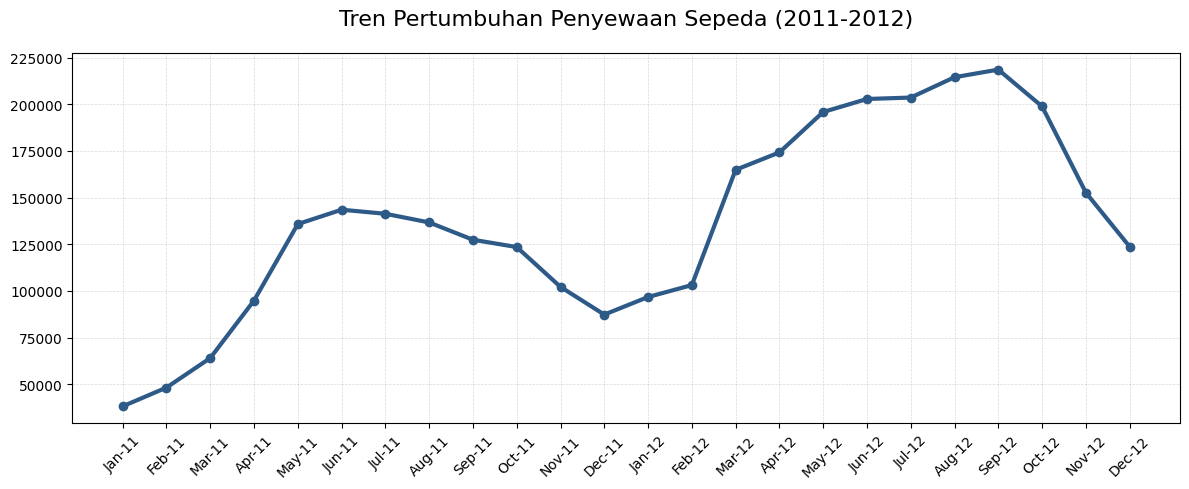

In [18]:
monthly_rent_df = day_df.resample(rule='M', on='dteday').agg({
    "cnt": "sum"
})
monthly_rent_df.index = monthly_rent_df.index.strftime('%b-%y')
monthly_rent_df = monthly_rent_df.reset_index()

plt.figure(figsize=(12, 5))
plt.plot(monthly_rent_df['dteday'], monthly_rent_df['cnt'], marker='o', linewidth=3, color="#2E5A88") # Biru gelap profesional
plt.title("Tren Pertumbuhan Penyewaan Sepeda (2011-2012)", loc="center", fontsize=16, pad=20)
plt.xticks(fontsize=10, rotation=45)
plt.yticks(fontsize=10)
plt.grid(color='grey', linestyle='--', linewidth=0.5, alpha=0.3)
plt.tight_layout()
plt.show()

### Pertanyaan 2:

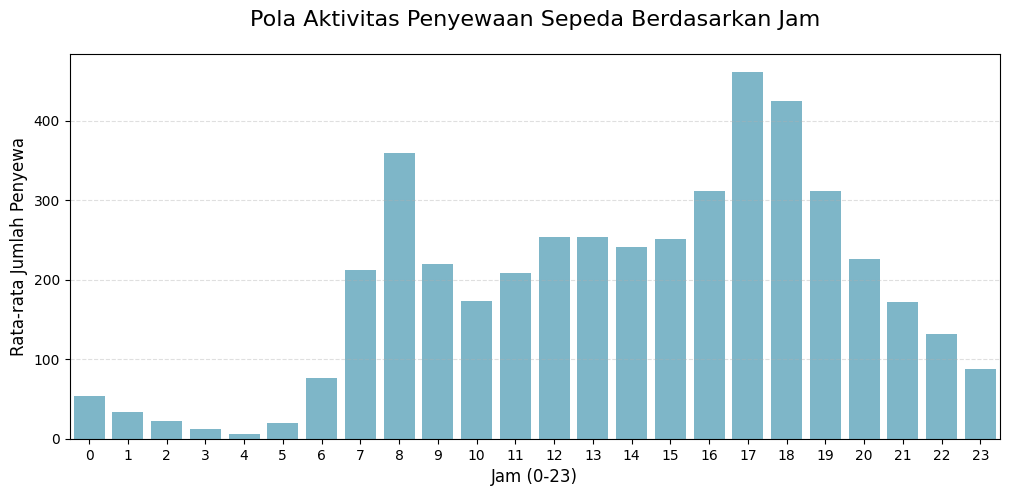

In [19]:
hourly_rent_df = hour_df.groupby("hr").cnt.mean().reset_index()

plt.figure(figsize=(12, 5))
sns.barplot(
    x="hr",
    y="cnt",
    data=hourly_rent_df,
    color="#72BCD4"
)

plt.title("Pola Aktivitas Penyewaan Sepeda Berdasarkan Jam", loc="center", fontsize=16, pad=20)
plt.xlabel("Jam (0-23)", fontsize=12)
plt.ylabel("Rata-rata Jumlah Penyewa", fontsize=12)
plt.xticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

**Insight:**
- Tren bulanan menunjukkan pertumbuhan yang sangat positif dari tahun 2011 ke 2012, dengan puncak penyewaan terjadi di pertengahan tahun sekitar bulan Juni-September.
- Sementara itu, visualisasi per jam menunjukkan pola dua puncak, di mana aktivitas penyewaan melonjak tajam pada pukul 08.00 pagi dan 17.00-18.00 sore. Pola ini mengindikasikan bahwa mayoritas pengguna menggunakan layanan sepeda sebagai moda transportasi rutin untuk aktivitas komuter pergi dan pulang kantor/sekolah.

In [20]:
all_df = pd.merge(
    left=day_df,
    right=hour_df,
    on="dteday",
    how="left",
    suffixes=('_daily', '_hourly')
)

all_df.head()

,instant_daily,dteday,season_daily,yr_daily,mnth_daily,holiday_daily,weekday_daily,workingday_daily,weathersit_daily,temp_daily,...,weekday_hourly,workingday_hourly,weathersit_hourly,temp_hourly,atemp_hourly,hum_hourly,windspeed_hourly,casual_hourly,registered_hourly,cnt_hourly
0,1,2011-01-01,Spring,2011,1,0,6,0,2,344.167,...,6,0,1,0.24,2.879,0.81,0.0,3,13,16
1,1,2011-01-01,Spring,2011,1,0,6,0,2,344.167,...,6,0,1,0.22,2.727,0.80,0.0,8,32,40
2,1,2011-01-01,Spring,2011,1,0,6,0,2,344.167,...,6,0,1,0.22,2.727,0.80,0.0,5,27,32
3,1,2011-01-01,Spring,2011,1,0,6,0,2,344.167,...,6,0,1,0.24,2.879,0.75,0.0,3,10,13
4,1,2011-01-01,Spring,2011,1,0,6,0,2,344.167,...,6,0,1,0.24,2.879,0.75,0.0,0,1,1


In [21]:
all_df.to_csv("main_data.csv", index=False)

## Analisis Lanjutan (Opsional)

## Conclusion

- Optimalisasi Armada pada Jam Sibuk:
Mengingat adanya lonjakan penyewaan yang signifikan pada pukul 08:00 pagi dan 17:00 sore, perusahaan disarankan untuk memastikan ketersediaan unit sepeda dan kesiapan staf pemeliharaan di titik-titik stasiun yang dekat dengan kawasan perkantoran atau transportasi umum pada jam tersebut. Hal ini bertujuan untuk meminimalisir potensi kegagalan sewa akibat kehabisan stok unit saat permintaan mencapai puncaknya (hingga 461 unit rata-rata).
- Strategi Pemasaran dan Perawatan di Musim Rendah:
Data menunjukkan penurunan drastis pada Musim Semi (Spring) dengan rata-rata hanya 2.604 unit, sementara Musim Gugur (Fall) mencapai performa tertinggi. Stakeholder dapat mempertimbangkan pemberian promo khusus atau diskon pada musim semi untuk merangsang minat pengguna. Selain itu, periode rendah ini dapat dimanfaatkan sebagai waktu utama untuk melakukan perawatan besar-besaran (overhaul) pada armada agar kondisi sepeda tetap prima saat memasuki musim sibuk seperti musim gugur